In [1]:
!pip -q install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.0 MB/s eta 0:00:00


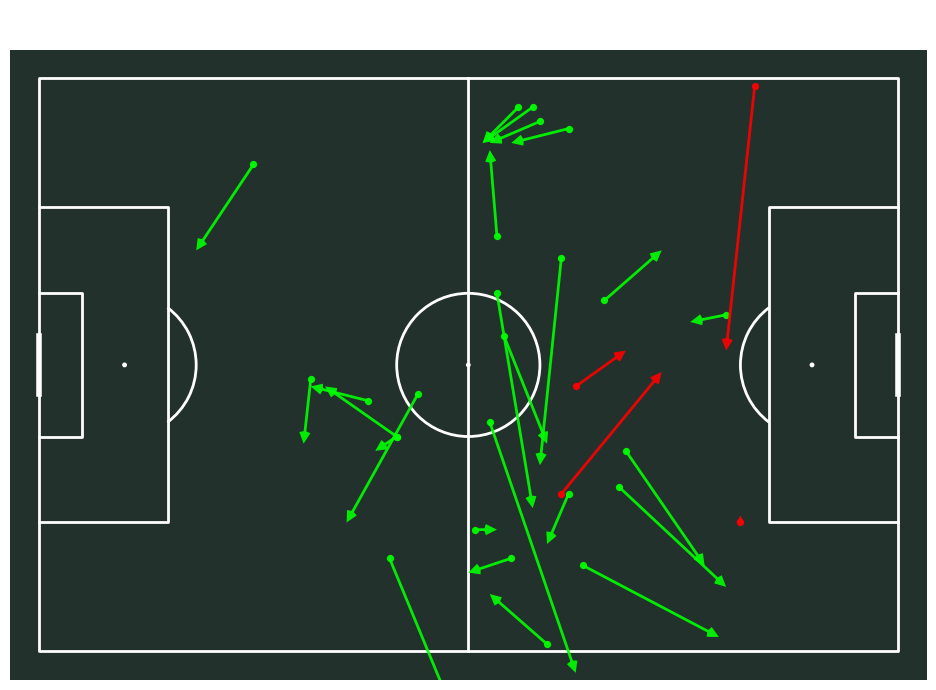

In [3]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

import pandas as pd
#PRIMERO SUBIR A LA CARPETA RAIZ EL ARCHIVO messi_pases.csv
df = pd.read_csv("messi_pases.csv")
df.head()



# Asegurar numéricos
for c in ["x", "y", "endX", "endY"]:
    df[c] = df[c].astype(float)

# Separar por outcome
ok = df[df["outcome"].str.lower().eq("successful")]
bad = df[df["outcome"].str.lower().eq("unsuccessful")]

# Pitch estilo StatsBomb (120x80)
pitch = Pitch(pitch_type="statsbomb", pitch_color="#22312b", line_color="white")
fig, ax = pitch.draw(figsize=(14, 7))

# Verdes = successful
pitch.arrows(
    ok["x"], ok["y"], ok["endX"], ok["endY"],
    ax=ax, width=2, headwidth=4, headlength=4,
    color="lime", alpha=0.9
)
pitch.scatter(ok["x"], ok["y"], ax=ax, s=18, color="lime", alpha=0.9)

# Rojos = unsuccessful
pitch.arrows(
    bad["x"], bad["y"], bad["endX"], bad["endY"],
    ax=ax, width=2, headwidth=4, headlength=4,
    color="red", alpha=0.9
)
pitch.scatter(bad["x"], bad["y"], ax=ax, s=18, color="red", alpha=0.9)

ax.set_title("Mapa de Pases de Messi vs Betis", fontsize=18, color="white", pad=15)
plt.show()

In [4]:
# Convertir de 0-100 a StatsBomb 120x80
df["x"]    = df["x"]    * 120 / 100
df["endX"] = df["endX"] * 120 / 100
df["y"]    = df["y"]    * 80  / 100
df["endY"] = df["endY"] * 80  / 100

In [5]:
df = df[df["player"].str.contains("messi", case=False, na=False)]